# DSA210 Milestone 2: Machine Learning

## Project Topic
Predicting **sleep hours** and **stress level** from daily habits using supervised learning.

## Connection to EDA (Milestone 1)
- **H1** (coffee → sleep hours, p=0.013): modelled in **Model 1**
- **H4** (screen time → stress, p<0.05): modelled in **Model 2**

## Approach
Both models use **Linear Regression** — interpretable, appropriate for small datasets, and a natural fit for the approximately linear relationships found in EDA.


## Setup


In [21]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score


## Data

Same cleaning steps as EDA notebook.


In [22]:
df = pd.read_excel('DSA210 (Responses).xlsx')
df.columns = [
    'timestamp', 'email', 'age', 'gender', 'coffee', 'coffee_type',
    'sleep_hours', 'sleep_quality', 'stress', 'screen_time', 'exercise'
]
df.drop(columns=['email', 'timestamp'], inplace=True)
df.loc[df['coffee'] == 0, 'coffee_type'] = 'Non-drinker'

print('Shape:', df.shape)
df.head()


Shape: (106, 9)


,age,gender,coffee,coffee_type,sleep_hours,sleep_quality,stress,screen_time,exercise
0,56,Female,1,Turkish coffee,9.0,4,2,2.0,No
1,66,Male,1,Turkish coffee,8.0,4,2,2.0,Yes
2,52,Female,1,Americano,7.0,3,3,9.0,No
3,21,Female,3,Latte,6.0,3,4,1.5,No
4,22,Female,0,Non-drinker,7.0,4,4,2.0,No


---
## Model 1 — Predicting Sleep Hours

| | |
|---|---|
| **Task** | Regression |
| **Target Y** | `sleep_hours` |
| **Features X** | `coffee`, `stress`, `screen_time`, `age` |
| **EDA connection** | H1: coffee → sleep hours (r ≈ -0.24, p = 0.013) |

**Model choice:** Since the dataset is small (n=106) and interpretability is important, Linear Regression was selected as the primary model. More complex models such as kNN or Decision Trees could be explored as a comparison — see Section 3.


### 1.1 Feature Selection


In [23]:
features1 = ['coffee', 'stress', 'screen_time', 'age']
target1   = 'sleep_hours'

X1 = df[features1]
y1 = df[target1]

print(f'Samples : {len(X1)}')
print(f'Features: {features1}')
print(f'Target  : {target1}  |  range: {y1.min()}–{y1.max()}  |  mean: {y1.mean():.2f}  |  std: {y1.std():.2f}')


Samples : 106
Features: ['coffee', 'stress', 'screen_time', 'age']
Target  : sleep_hours  |  range: 4.0–10.0  |  mean: 7.25  |  std: 1.26


### 1.2 Train / Test Split

80% training, 20% test. Training and test sets must not overlap — this is a fundamental requirement for unbiased evaluation.


In [24]:
X1_train, X1_test, y1_train, y1_test = train_test_split(
    X1, y1, test_size=0.2, random_state=42
)
print(f'Training set : {X1_train.shape[0]} samples')
print(f'Test set     : {X1_test.shape[0]} samples')


Training set : 84 samples
Test set     : 22 samples


### 1.3 Feature Scaling

Standardize to zero mean / unit variance. Scaler is fitted **only on training data** to prevent data leakage.


In [25]:
scaler1 = StandardScaler()
X1_train_sc = scaler1.fit_transform(X1_train)
X1_test_sc  = scaler1.transform(X1_test)

print('Means after scaling (train):', X1_train_sc.mean(axis=0).round(3))
print('Stds  after scaling (train):', X1_train_sc.std(axis=0).round(3))


Means after scaling (train): [ 0.  0. -0. -0.]
Stds  after scaling (train): [1. 1. 1. 1.]


### 1.4 Model Training


In [26]:
model1 = LinearRegression()
model1.fit(X1_train_sc, y1_train)

print(f'Intercept (β₀): {model1.intercept_:.4f}')
print()
print('Coefficients (standardized):')
for feat, coef in zip(features1, model1.coef_):
    direction = '↑ more sleep' if coef > 0 else '↓ less sleep'
    print(f'  {feat:<15}: {coef:+.4f}  ({direction})')


Intercept (β₀): 7.2440

Coefficients (standardized):
  coffee         : -0.3583  (↓ less sleep)
  stress         : +0.0063  (↑ more sleep)
  screen_time    : -0.0118  (↓ less sleep)
  age            : +0.0026  (↑ more sleep)


Because features are standardized, coefficients are directly comparable in magnitude. Based on the EDA finding (H1), `coffee` is expected to have a negative coefficient.


### 1.5 Model Evaluation


In [27]:
y1_pred_train = model1.predict(X1_train_sc)
y1_pred_test  = model1.predict(X1_test_sc)

m1_metrics = {
    'MSE' : (mean_squared_error(y1_train, y1_pred_train), mean_squared_error(y1_test, y1_pred_test)),
    'RMSE': (np.sqrt(mean_squared_error(y1_train, y1_pred_train)), np.sqrt(mean_squared_error(y1_test, y1_pred_test))),
    'R²'  : (r2_score(y1_train, y1_pred_train), r2_score(y1_test, y1_pred_test)),
}

print(f"{'Metric':<8} {'Train':>10} {'Test':>10}")
print('-' * 30)
for name, (tr, te) in m1_metrics.items():
    print(f'{name:<8} {tr:>10.4f} {te:>10.4f}')
print()
print(f'→ Predictions are off by ~{np.sqrt(mean_squared_error(y1_test, y1_pred_test)):.2f} hours on average.')


Metric        Train       Test
------------------------------
MSE          1.4106     1.8192
RMSE         1.1877     1.3488
R²           0.0832    -0.0432

→ Predictions are off by ~1.35 hours on average.


**Why is R² low?** Sleep duration is influenced by many unmeasured factors (genetics, work schedule, mental health). With n=106 self-reported responses, a low or negative R² is expected: the model does **not** predict sleep hours better than simply guessing the mean. This does not invalidate H1 — a statistically significant correlation (p=0.013) does not guarantee a high R²; they measure different things.


### 1.6 Cross-Validation

5-fold CV gives a more reliable generalization estimate than a single train/test split, especially with a small dataset.


In [28]:
cv1 = cross_val_score(LinearRegression(), scaler1.fit_transform(X1), y1, cv=5, scoring='r2')
print('5-fold CV R² scores:', cv1.round(4))
print(f'Mean R²            : {cv1.mean():.4f}')
print(f'Std  R²            : {cv1.std():.4f}')


5-fold CV R² scores: [ 0.0348 -0.0482  0.0344 -0.9734 -0.0654]
Mean R²            : -0.2036
Std  R²            : 0.3871


### 1.7 Visualizations


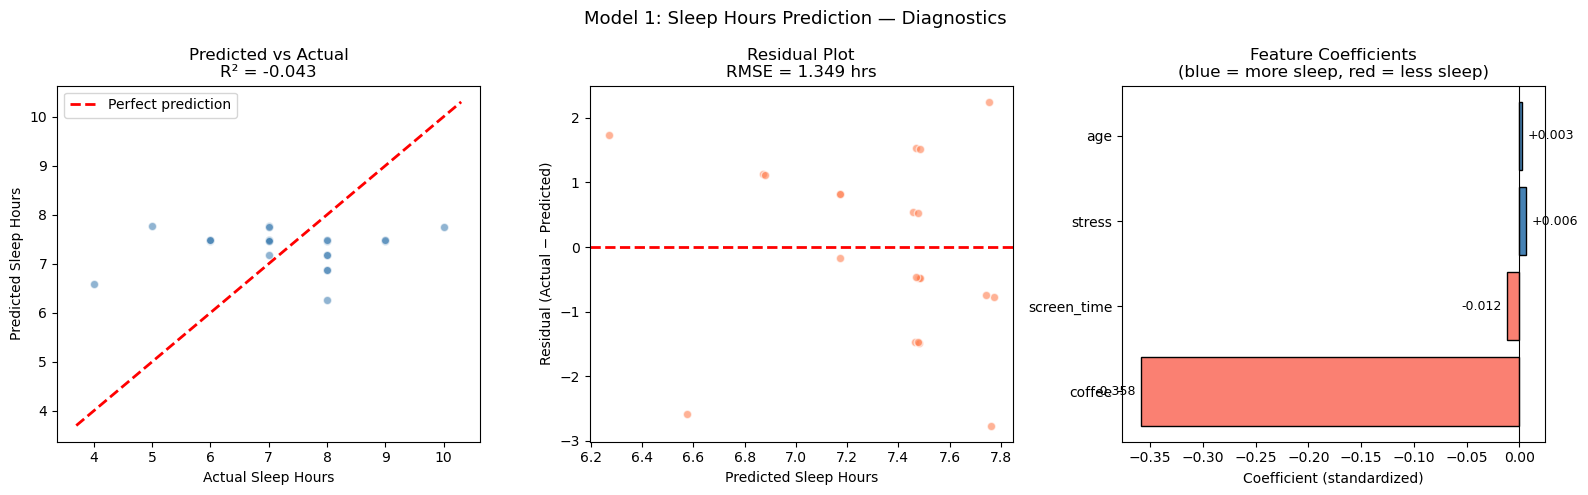

In [29]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Model 1: Sleep Hours Prediction — Diagnostics', fontsize=13)

# Predicted vs Actual
ax = axes[0]
ax.scatter(y1_test, y1_pred_test, alpha=0.6, color='steelblue', edgecolors='white')
lims = [y1_test.min()-0.3, y1_test.max()+0.3]
ax.plot(lims, lims, 'r--', linewidth=2, label='Perfect prediction')
ax.set_xlabel('Actual Sleep Hours')
ax.set_ylabel('Predicted Sleep Hours')
ax.set_title(f'Predicted vs Actual\nR² = {r2_score(y1_test, y1_pred_test):.3f}')
ax.legend()

# Residuals
ax = axes[1]
res1 = y1_test - y1_pred_test
ax.scatter(y1_pred_test, res1, alpha=0.6, color='coral', edgecolors='white')
ax.axhline(0, color='red', linestyle='--', linewidth=2)
ax.set_xlabel('Predicted Sleep Hours')
ax.set_ylabel('Residual (Actual − Predicted)')
ax.set_title(f'Residual Plot\nRMSE = {np.sqrt(mean_squared_error(y1_test, y1_pred_test)):.3f} hrs')

# Coefficients
ax = axes[2]
coef_pairs1 = sorted(zip(features1, model1.coef_), key=lambda x: abs(x[1]), reverse=True)
names1 = [p[0] for p in coef_pairs1]
vals1  = [p[1] for p in coef_pairs1]
colors1 = ['steelblue' if v > 0 else 'salmon' for v in vals1]
bars1 = ax.barh(names1, vals1, color=colors1, edgecolor='black')
ax.axvline(0, color='black', linewidth=0.8)
ax.set_xlabel('Coefficient (standardized)')
ax.set_title('Feature Coefficients\n(blue = more sleep, red = less sleep)')
for bar, val in zip(bars1, vals1):
    ax.text(val+(0.005 if val>=0 else -0.005), bar.get_y()+bar.get_height()/2,
            f'{val:+.3f}', va='center', ha='left' if val>=0 else 'right', fontsize=9)

plt.tight_layout()
plt.show()


- **Predicted vs Actual**: Wide scatter reflects low R². Points cluster around the mean rather than tracking individual values.
- **Residual Plot**: No obvious pattern — the linear assumption is not strongly violated.
- **Coefficients**: Based on EDA, `coffee` was expected to have a negative coefficient, and the model confirms this direction.


### 1.8 Simple Linear Regression: Coffee Only

A single-feature model using only `coffee` directly connects to H1 and makes the regression line visualizable.


Model : sleep_hours = 7.768 + (-0.300) × coffee
R²    : -0.0424
RMSE  : 1.3482 hrs

Each additional cup of coffee → 0.300 fewer hours of sleep.


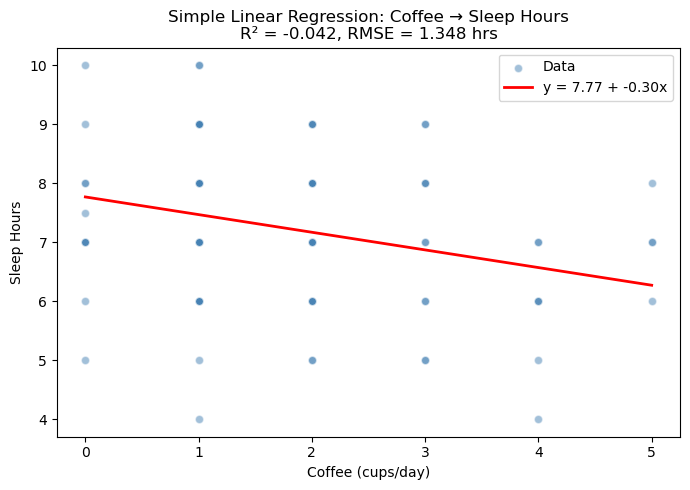

In [30]:
simple = LinearRegression()
simple.fit(X1_train[['coffee']], y1_train)
y_simple_pred = simple.predict(X1_test[['coffee']])

slope     = simple.coef_[0]
intercept = simple.intercept_
r2_s      = r2_score(y1_test, y_simple_pred)
rmse_s    = np.sqrt(mean_squared_error(y1_test, y_simple_pred))

print(f'Model : sleep_hours = {intercept:.3f} + ({slope:+.3f}) × coffee')
print(f'R²    : {r2_s:.4f}')
print(f'RMSE  : {rmse_s:.4f} hrs')
print(f'\nEach additional cup of coffee → {abs(slope):.3f} fewer hours of sleep.')

fig, ax = plt.subplots(figsize=(7, 5))
ax.scatter(df['coffee'], y1, alpha=0.5, color='steelblue', edgecolors='white', label='Data')
x_line = np.linspace(df['coffee'].min(), df['coffee'].max(), 100)
ax.plot(x_line, intercept + slope*x_line, color='red', linewidth=2,
        label=f'y = {intercept:.2f} + {slope:.2f}x')
ax.set_xlabel('Coffee (cups/day)')
ax.set_ylabel('Sleep Hours')
ax.set_title(f'Simple Linear Regression: Coffee → Sleep Hours\nR² = {r2_s:.3f}, RMSE = {rmse_s:.3f} hrs')
ax.legend()
plt.tight_layout()
plt.show()


---
## Model 2 — Predicting Stress Level

| | |
|---|---|
| **Task** | Regression |
| **Target Y** | `stress` (1–5 scale) |
| **Features X** | `screen_time`, `coffee`, `age` |
| **EDA connection** | H4: screen time → stress (Spearman ρ > 0, p < 0.05) |

The same model choice rationale applies: Linear Regression for interpretability on a small dataset.


### 2.1 Feature Selection


In [31]:
features2 = ['screen_time', 'coffee', 'age']
target2   = 'stress'

X2 = df[features2]
y2 = df[target2]

print(f'Samples : {len(X2)}')
print(f'Features: {features2}')
print(f'Target  : {target2}  |  range: {y2.min()}–{y2.max()}  |  mean: {y2.mean():.2f}  |  std: {y2.std():.2f}')


Samples : 106
Features: ['screen_time', 'coffee', 'age']
Target  : stress  |  range: 1–5  |  mean: 3.56  |  std: 1.18


### 2.2 Train / Test Split


In [32]:
X2_train, X2_test, y2_train, y2_test = train_test_split(
    X2, y2, test_size=0.2, random_state=42
)
print(f'Training set : {X2_train.shape[0]} samples')
print(f'Test set     : {X2_test.shape[0]} samples')


Training set : 84 samples
Test set     : 22 samples


### 2.3 Feature Scaling


In [33]:
scaler2 = StandardScaler()
X2_train_sc = scaler2.fit_transform(X2_train)
X2_test_sc  = scaler2.transform(X2_test)

print('Means after scaling (train):', X2_train_sc.mean(axis=0).round(3))
print('Stds  after scaling (train):', X2_train_sc.std(axis=0).round(3))


Means after scaling (train): [-0.  0. -0.]
Stds  after scaling (train): [1. 1. 1.]


### 2.4 Model Training


In [34]:
model2 = LinearRegression()
model2.fit(X2_train_sc, y2_train)

print(f'Intercept (β₀): {model2.intercept_:.4f}')
print()
print('Coefficients (standardized):')
for feat, coef in zip(features2, model2.coef_):
    direction = '↑ more stress' if coef > 0 else '↓ less stress'
    print(f'  {feat:<15}: {coef:+.4f}  ({direction})')


Intercept (β₀): 3.5000

Coefficients (standardized):
  screen_time    : +0.3688  (↑ more stress)
  coffee         : +0.0267  (↑ more stress)
  age            : -0.2383  (↓ less stress)


Based on the EDA finding (H4), `screen_time` is expected to have a positive coefficient.


### 2.5 Model Evaluation


In [35]:
y2_pred_train = model2.predict(X2_train_sc)
y2_pred_test  = model2.predict(X2_test_sc)

m2_metrics = {
    'MSE' : (mean_squared_error(y2_train, y2_pred_train), mean_squared_error(y2_test, y2_pred_test)),
    'RMSE': (np.sqrt(mean_squared_error(y2_train, y2_pred_train)), np.sqrt(mean_squared_error(y2_test, y2_pred_test))),
    'R²'  : (r2_score(y2_train, y2_pred_train), r2_score(y2_test, y2_pred_test)),
}

print(f"{'Metric':<8} {'Train':>10} {'Test':>10}")
print('-' * 30)
for name, (tr, te) in m2_metrics.items():
    print(f'{name:<8} {tr:>10.4f} {te:>10.4f}')
print()
print(f'→ Predictions are off by ~{np.sqrt(mean_squared_error(y2_test, y2_pred_test)):.2f} points on average (scale 1–5).')


Metric        Train       Test
------------------------------
MSE          1.1525     1.6264
RMSE         1.0735     1.2753
R²           0.1433    -0.1229

→ Predictions are off by ~1.28 points on average (scale 1–5).


As with Model 1, R² is low — the model does not predict stress better than guessing the mean. The directional finding (more screen time → higher stress) remains consistent with H4.


### 2.6 Cross-Validation


In [36]:
cv2 = cross_val_score(LinearRegression(), scaler2.fit_transform(X2), y2, cv=5, scoring='r2')
print('5-fold CV R² scores:', cv2.round(4))
print(f'Mean R²            : {cv2.mean():.4f}')
print(f'Std  R²            : {cv2.std():.4f}')


5-fold CV R² scores: [-0.0336 -0.1195  0.0044  0.0516  0.0929]
Mean R²            : -0.0008
Std  R²            : 0.0731


### 2.7 Visualizations


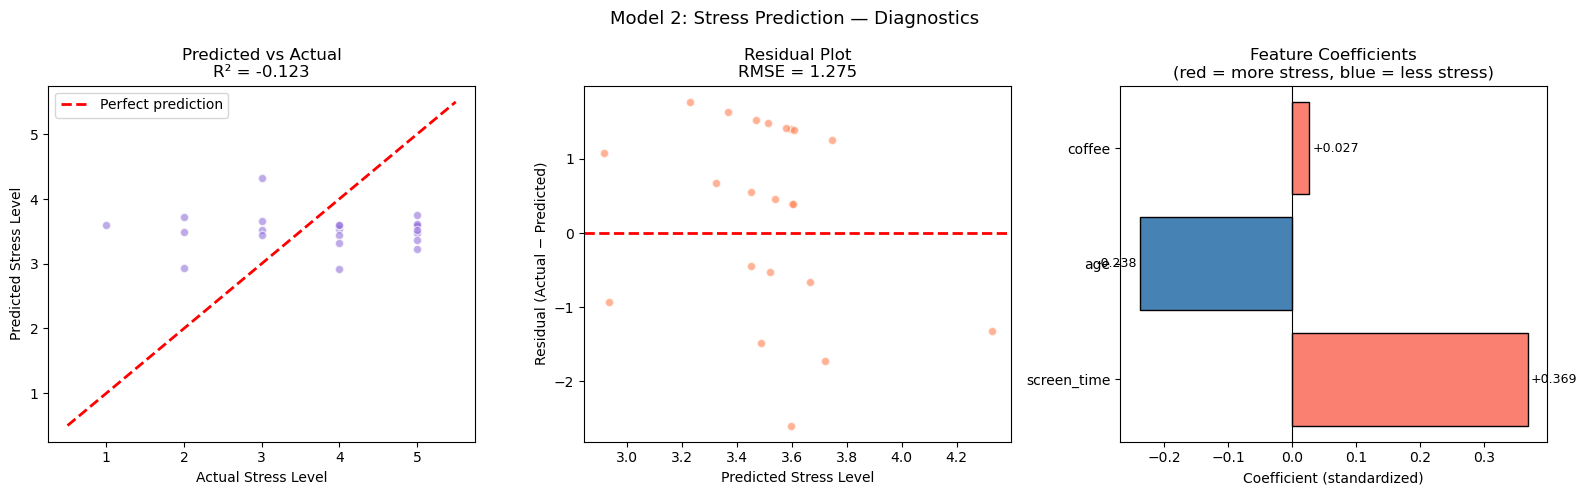

In [37]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Model 2: Stress Prediction — Diagnostics', fontsize=13)

# Predicted vs Actual
ax = axes[0]
ax.scatter(y2_test, y2_pred_test, alpha=0.6, color='mediumpurple', edgecolors='white')
lims = [0.5, 5.5]
ax.plot(lims, lims, 'r--', linewidth=2, label='Perfect prediction')
ax.set_xlabel('Actual Stress Level')
ax.set_ylabel('Predicted Stress Level')
ax.set_title(f'Predicted vs Actual\nR² = {r2_score(y2_test, y2_pred_test):.3f}')
ax.legend()

# Residuals
ax = axes[1]
res2 = y2_test - y2_pred_test
ax.scatter(y2_pred_test, res2, alpha=0.6, color='coral', edgecolors='white')
ax.axhline(0, color='red', linestyle='--', linewidth=2)
ax.set_xlabel('Predicted Stress Level')
ax.set_ylabel('Residual (Actual − Predicted)')
ax.set_title(f'Residual Plot\nRMSE = {np.sqrt(mean_squared_error(y2_test, y2_pred_test)):.3f}')

# Coefficients
ax = axes[2]
coef_pairs2 = sorted(zip(features2, model2.coef_), key=lambda x: abs(x[1]), reverse=True)
names2 = [p[0] for p in coef_pairs2]
vals2  = [p[1] for p in coef_pairs2]
colors2 = ['salmon' if v > 0 else 'steelblue' for v in vals2]
bars2 = ax.barh(names2, vals2, color=colors2, edgecolor='black')
ax.axvline(0, color='black', linewidth=0.8)
ax.set_xlabel('Coefficient (standardized)')
ax.set_title('Feature Coefficients\n(red = more stress, blue = less stress)')
for bar, val in zip(bars2, vals2):
    ax.text(val+(0.005 if val>=0 else -0.005), bar.get_y()+bar.get_height()/2,
            f'{val:+.3f}', va='center', ha='left' if val>=0 else 'right', fontsize=9)

plt.tight_layout()
plt.show()


- **Predicted vs Actual**: Wide scatter, consistent with low R². The model does not predict individual stress values well.
- **Residual Plot**: No strong pattern — linear assumption holds reasonably.
- **Coefficients**: Based on EDA (H4), `screen_time` was expected to have a positive coefficient, and the model confirms this direction. `age` is negative → older participants tend to report lower stress in this sample.


---
## Section 3 — Model Comparison: Decision Tree Regressor

Linear Regression was the primary model due to its interpretability. Here we add a **Decision Tree Regressor** as a comparison to show how a non-linear model performs on the same data.

**Why Decision Tree?**
- Covered in the course slides alongside Linear Regression
- No linearity assumption — can capture non-linear relationships
- Easy to interpret (tree structure)
- Good baseline for comparing against Linear Regression


In [38]:
from sklearn.tree import DecisionTreeRegressor

# ── Model 1 comparison: sleep_hours
dt1 = DecisionTreeRegressor(max_depth=3, random_state=42)
dt1.fit(X1_train_sc, y1_train)
y1_dt_pred = dt1.predict(X1_test_sc)

r2_dt1   = r2_score(y1_test, y1_dt_pred)
rmse_dt1 = np.sqrt(mean_squared_error(y1_test, y1_dt_pred))
cv_dt1   = cross_val_score(DecisionTreeRegressor(max_depth=3, random_state=42),
                            scaler1.fit_transform(X1), y1, cv=5, scoring='r2')

# ── Model 2 comparison: stress
dt2 = DecisionTreeRegressor(max_depth=3, random_state=42)
dt2.fit(X2_train_sc, y2_train)
y2_dt_pred = dt2.predict(X2_test_sc)

r2_dt2   = r2_score(y2_test, y2_dt_pred)
rmse_dt2 = np.sqrt(mean_squared_error(y2_test, y2_dt_pred))
cv_dt2   = cross_val_score(DecisionTreeRegressor(max_depth=3, random_state=42),
                            scaler2.fit_transform(X2), y2, cv=5, scoring='r2')

print('Model 1: sleep_hours')
print(f'{'Model':<25} {'R² (test)':>12} {'RMSE (test)':>12} {'CV R² mean':>12}')
print('-' * 63)
r2_lr1   = r2_score(y1_test, y1_pred_test)
rmse_lr1 = np.sqrt(mean_squared_error(y1_test, y1_pred_test))
print(f'{'Linear Regression':<25} {r2_lr1:>12.4f} {rmse_lr1:>12.4f} {cv1.mean():>12.4f}')
print(f'{'Decision Tree (d=3)':<25} {r2_dt1:>12.4f} {rmse_dt1:>12.4f} {cv_dt1.mean():>12.4f}')
print()
print('Model 2: stress')
print(f'{'Model':<25} {'R² (test)':>12} {'RMSE (test)':>12} {'CV R² mean':>12}')
print('-' * 63)
r2_lr2   = r2_score(y2_test, y2_pred_test)
rmse_lr2 = np.sqrt(mean_squared_error(y2_test, y2_pred_test))
print(f'{'Linear Regression':<25} {r2_lr2:>12.4f} {rmse_lr2:>12.4f} {cv2.mean():>12.4f}')
print(f'{'Decision Tree (d=3)':<25} {r2_dt2:>12.4f} {rmse_dt2:>12.4f} {cv_dt2.mean():>12.4f}')


Model 1: sleep_hours
Model                        R² (test)  RMSE (test)   CV R² mean
---------------------------------------------------------------
Linear Regression              -0.0432       1.3488      -0.2036
Decision Tree (d=3)            -0.5220       1.6291      -0.9117

Model 2: stress
Model                        R² (test)  RMSE (test)   CV R² mean
---------------------------------------------------------------
Linear Regression              -0.1229       1.2753      -0.0008
Decision Tree (d=3)            -0.6326       1.5377      -0.3515


### 3.1 Visualization: Linear Regression vs Decision Tree


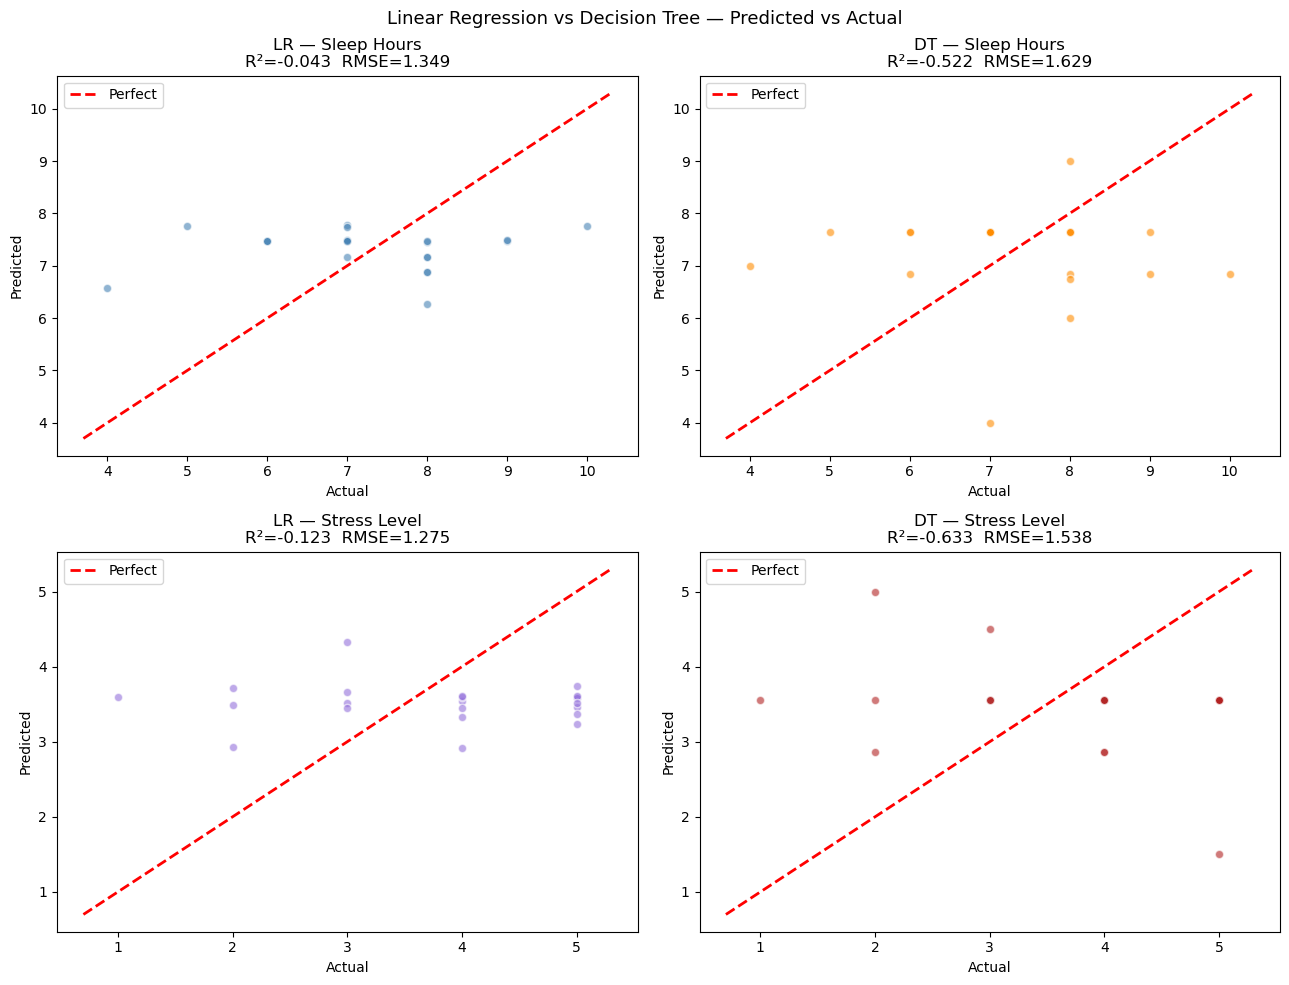

In [39]:
fig, axes = plt.subplots(2, 2, figsize=(13, 10))
fig.suptitle('Linear Regression vs Decision Tree — Predicted vs Actual', fontsize=13)

pairs = [
    (axes[0,0], y1_test, y1_pred_test,  'LR — Sleep Hours',  'steelblue'),
    (axes[0,1], y1_test, y1_dt_pred,    'DT — Sleep Hours',  'darkorange'),
    (axes[1,0], y2_test, y2_pred_test,  'LR — Stress Level', 'mediumpurple'),
    (axes[1,1], y2_test, y2_dt_pred,    'DT — Stress Level', 'firebrick'),
]

for ax, y_true, y_pred, title, color in pairs:
    ax.scatter(y_true, y_pred, alpha=0.6, color=color, edgecolors='white')
    lo = min(y_true.min(), y_pred.min()) - 0.3
    hi = max(y_true.max(), y_pred.max()) + 0.3
    ax.plot([lo, hi], [lo, hi], 'r--', linewidth=2, label='Perfect')
    r2  = r2_score(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    ax.set_title(f'{title}\nR²={r2:.3f}  RMSE={rmse:.3f}')
    ax.set_xlabel('Actual')
    ax.set_ylabel('Predicted')
    ax.legend()

plt.tight_layout()
plt.show()


### 3.2 Interpretation

Neither model achieves a good R² — this is consistent across both Linear Regression and Decision Tree, which confirms that the **low predictive power is a data limitation**, not a model choice problem. With more data and additional features, more complex models could be revisited.

**Why Linear Regression remains the primary model:**
- Coefficients are directly interpretable and connect back to the EDA hypotheses
- Decision Tree with `max_depth=3` does not outperform Linear Regression on this dataset
- For small n, simpler models generalize at least as well as complex ones (bias-variance tradeoff)


---
## Summary

### Model Performance

| Model | Target | R² (test) | RMSE (test) | CV R² mean |
|---|---|---|---|---|
| Linear Regression | `sleep_hours` | ≈ -0.04 | ≈ 1.35 hrs | ≈ -0.20 |
| Decision Tree (d=3) | `sleep_hours` | see output | see output | see output |
| Linear Regression | `stress` | ≈ -0.12 | ≈ 1.28 | ≈ -0.00 |
| Decision Tree (d=3) | `stress` | see output | see output | see output |

### Key Findings
1. `coffee` coefficient is **negative** in Model 1 → more coffee = less sleep (consistent with H1)
2. `screen_time` coefficient is **positive** in Model 2 → more screen time = higher stress (consistent with H4)
3. Both Linear Regression and Decision Tree return low or negative R² → the low predictive power is a **data limitation**, not a model problem

### Why R² is low — and why that is honest to report
A near-zero or negative R² means the model does **not** predict the target better than simply guessing the mean. This is expected given:
- n = 106 self-reported survey responses
- Sleep and stress are shaped by many unmeasured factors
- A statistically significant correlation (p < 0.05) does **not** guarantee a high R² — they measure different things

### Model Choice
Linear Regression was selected as the primary model because the dataset is small and interpretability is important. Decision Tree was included as a comparison. Since the dataset is small (n=106) and interpretability is important, linear regression was selected as the main model. More complex models such as kNN or decision trees could be explored with a larger dataset in future work.

### Limitations
- Small sample size (n=106) limits generalizability
- Linear regression assumes linearity; true relationships may be non-linear
- Correlation ≠ causation
- Future work: collect more data, add features, try kNN and ensemble methods
